<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #4f46e5; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        El Algoritmo A* (A-Estrella): Búsqueda Óptima y Completa ⭐
      </h1>
      <p style="margin: 6px 0 0 0; color: #4f46e5; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Introducción a la Inteligencia Artificial
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #4f46e5; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 04 • Algoritmos de Búsqueda
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #4f46e5; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

---
## 1. A*: lo Mejor de Ambos Mundos (1.16.9) ⭐

En el cuaderno 02 vimos que **GBFS** puede ser rápido, pero se deja engañar fácilmente porque sólo mira `h(n)` (la estimación heurística) e ignora por completo `g(n)` (el costo real ya recorrido). En el cuaderno 01 vimos que **BFS** sí es óptimo (encuentra el camino más corto), pero paga ese precio explorando casi todo el árbol, sin usar ninguna pista.

**A\* (A-estrella)** combina ambas señales en una sola función de evaluación:

$$f(n) = g(n) + h(n)$$

* `g(n)`: costo real acumulado desde la raíz hasta el nodo `n` (en nuestro caso, 1 salto = costo 1).
* `h(n)`: estimación heurística del costo restante desde `n` hasta el objetivo.
* `f(n)`: costo **estimado total** de la mejor solución que pasa por `n`.

A* expande siempre el nodo de la frontera con **menor `f(n)`**. Si la heurística cumple dos propiedades —**admisibilidad** y **consistencia**— A* queda garantizado como:

| Propiedad | Definición | ¿Por qué se cumple? |
|---|---|---|
| **Completo** | Si existe una solución, A* la encuentra. | Al expandir siempre el `f(n)` mínimo entre nodos finitos, ningún nodo prometedor queda ignorado para siempre. |
| **Óptimo** | La solución encontrada tiene el **menor costo posible**. | Una heurística *admisible* nunca sobrestima el costo restante real, por lo que A* jamás descarta prematuramente un camino que podría ser mejor. |

**Heurística admisible:** $h(n) \leq h^*(n)$ para todo nodo `n`, donde $h^*(n)$ es el costo real (desconocido de antemano) del mejor camino desde `n` hasta el objetivo. Es decir, la heurística puede **subestimar**, pero nunca **sobrestimar**.

**Heurística consistente** (más fuerte que admisible): para toda arista $(n, n')$ con costo $c(n,n')$, se cumple $h(n) \leq c(n,n') + h(n')$. La consistencia es justo lo que necesitamos para poder usar A* con un conjunto de **cerrados** (nodos que, una vez expandidos, no se vuelven a considerar) sin perder la garantía de optimalidad.

---
## 2. Extendiendo el Sistema de Archivos: un Acceso Directo (Grafo) 🔗

En un **árbol** puro, sólo existe **un** camino posible hacia cualquier nodo — por eso, en los cuadernos 01 y 02, DFS, BFS y GBFS siempre terminaron encontrando el mismo camino único. Para demostrar de forma **concreta** la garantía de optimalidad de A*, necesitamos un escenario con **más de una ruta posible** hacia el objetivo, tal como ocurre en un sistema de archivos real cuando existen **accesos directos** (*symlinks*).

Extendemos nuestro árbol con una carpeta `AccesosDirectos` en la raíz, que contiene una referencia directa a la misma carpeta `Informes` del Proyecto Norte —el mismo objeto, no una copia—. Esto convierte nuestro árbol en un **grafo dirigido acíclico (DAG)** con dos rutas hacia `informe_final.pdf`:

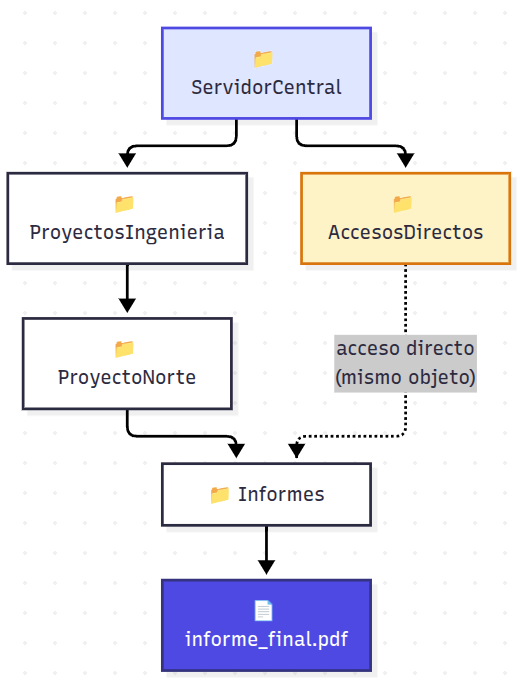

* **Ruta larga (4 saltos):** `ServidorCentral → ProyectosIngenieria → ProyectoNorte → Informes → informe_final.pdf`
* **Ruta corta (3 saltos):** `ServidorCentral → AccesosDirectos → Informes → informe_final.pdf`

Esta extensión vive en [`file_search_astar.py`](file_search_astar.py), en la función `agregar_acceso_directo()`.

In [ ]:
import sys
sys.path.append('.')

from file_search import construir_sistema_archivos, imprimir_arbol, dfs_buscar, bfs_buscar, resumen_resultado
from file_search_gbfs import gbfs_buscar
from file_search_astar import agregar_acceso_directo, calcular_heuristica_admisible, astar_buscar
import inspect

objetivo = "informe_final.pdf"

raiz = construir_sistema_archivos()
agregar_acceso_directo(raiz, objetivo)
calcular_heuristica_admisible(raiz, objetivo)

print("Sistema de archivos EXTENDIDO con acceso directo (ahora es un grafo):\n")
imprimir_arbol(raiz)

---
## 3. La Heurística Admisible: cómo se calculó `h(n)` aquí 🧮

En lugar de una heurística "de sentido común" como en GBFS, aquí construimos una heurística **admisible por diseño**: simulamos que el sistema ya cuenta con un **índice previo** de sus carpetas (algo común en sistemas de archivos reales, como *Spotlight* en macOS o *Windows Search*). Con ese índice:

1. Ubicamos el nodo objetivo dentro del grafo.
2. Hacemos un recorrido **hacia atrás** (de cada nodo hacia sus padres) partiendo del objetivo, calculando la distancia real mínima (en saltos) desde cada nodo hasta él.
3. A los nodos desde los que el objetivo **no** es alcanzable les asignamos, de forma conservadora, la profundidad máxima conocida del árbol — un valor que nunca sobrestima, porque ningún archivo real está más lejos que eso.

El resultado es una heurística que da el **mismo valor** para la carpeta `Informes` sin importar por cuál de sus dos rutas se llegue a ella (porque es, literalmente, el mismo objeto en memoria) — esto es justamente lo que la hace **consistente**.

In [ ]:
print(inspect.getsource(calcular_heuristica_admisible))

In [ ]:
# Heurística precalculada para los nodos clave de la ruta
def _buscar_por_nombre(nodo, nombre, vistos=None):
    vistos = vistos if vistos is not None else set()
    if id(nodo) in vistos:
        return []
    vistos.add(id(nodo))
    encontrados = [nodo] if nodo.nombre == nombre else []
    for hijo in nodo.hijos:
        encontrados += _buscar_por_nombre(hijo, nombre, vistos)
    return encontrados

print(f"{'Nodo':<22} | h(n) = saltos reales restantes hasta el objetivo")
print("-" * 65)
for nombre in ["ServidorCentral", "AccesosDirectos", "ProyectosIngenieria",
               "ProyectoNorte", "Informes", "informe_final.pdf"]:
    nodo_encontrado = _buscar_por_nombre(raiz, nombre)[0]
    print(f"{nombre:<22} | h = {nodo_encontrado.h_astar}")

Nótese que `h('AccesosDirectos') = 2` es exacto (2 saltos reales: `AccesosDirectos → Informes → informe_final.pdf`), y que `h('Informes') = 1` es el **mismo valor** sin importar si se llega a esa carpeta por la ruta larga o por el acceso directo — justo la propiedad de consistencia que A* necesita.

---
## 4. Implementación de A* 🧑‍💻

A* organiza la frontera como una **cola de prioridad** ordenada por `f(n) = g(n) + h(n)`, y usa un conjunto de **cerrados**: como la heurística es consistente, la primera vez que un nodo sale de la cola de prioridad, es garantizado que fue alcanzado por su camino de **menor costo posible**.

In [ ]:
print(inspect.getsource(astar_buscar))

---
## 5. Ejecución: A* Encuentra el Camino Óptimo 🏆

In [ ]:
resultado_astar = astar_buscar(raiz, objetivo)

print(resumen_resultado("A*", resultado_astar))
print(f"\nOrden de exploración A* ({len(resultado_astar['orden_visita'])} nodos):")
print("  " + " → ".join(resultado_astar["orden_visita"]))

assert resultado_astar["profundidad"] == 3, "A* debe encontrar la ruta óptima de 3 saltos."
print("\n✅ A* encontró el camino de COSTO MÍNIMO: 3 saltos, vía el acceso directo.")

---
## 6. Comparación Final: A\* vs. GBFS vs. BFS vs. DFS 📊

Ejecutamos los **cuatro** algoritmos sobre el **mismo grafo extendido** (con el acceso directo) para una comparación justa: ¿cuántos nodos expande cada uno, y encuentra o no el camino óptimo de 3 saltos?

In [ ]:
resultado_dfs = dfs_buscar(raiz, objetivo)
resultado_bfs = bfs_buscar(raiz, objetivo)
resultado_gbfs = gbfs_buscar(raiz, objetivo)

CAMINO_OPTIMO = 3  # saltos, vía AccesosDirectos

print(f"{'Algoritmo':<10} | {'Nodos expandidos':<18} | {'Saltos en el camino':<20} | ¿Óptimo?")
print("-" * 72)
for nombre_algo, resultado in [("DFS", resultado_dfs), ("BFS", resultado_bfs),
                                ("GBFS", resultado_gbfs), ("A*", resultado_astar)]:
    saltos = resultado["profundidad"]
    es_optimo = "✅ Sí" if saltos == CAMINO_OPTIMO else "❌ No"
    print(f"{nombre_algo:<10} | {resultado['nodos_expandidos']:<18} | {saltos!s:<20} | {es_optimo}")

### 🔬 Lectura de la tabla comparativa (resultado real de la ejecución)

| Algoritmo | Nodos expandidos | Camino (saltos) | ¿Óptimo? | Comentario |
|---|---|---|---|---|
| **DFS** | 26 | 4 | ❌ No | Encuentra *una* solución válida, pero nunca "vio" el acceso directo porque se hundió primero en la rama de `ProyectosIngenieria` por la ruta larga. |
| **BFS** | 34 | 3 | ✅ Sí | Óptimo porque el costo es uniforme (1 por salto) y BFS explora por niveles: alcanza `AccesosDirectos` (profundidad 1) antes que la ruta larga (profundidad 4). Pero expande casi todo el grafo para lograrlo. |
| **GBFS** | 12 | 4 | ❌ No | Rápido, pero al ignorar `g(n)` nunca comparó el costo de ambas rutas: simplemente se quedó con el primer camino cuyo nombre "sonó bien". |
| **A\*** | 4 | 3 | ✅ Sí | **Lo mejor de ambos mundos**: encuentra el camino óptimo (3 saltos) expandiendo prácticamente el mínimo posible de nodos, porque su heurística consistente lo guía directamente hacia `AccesosDirectos` sin descartar la posibilidad de una ruta mejor. |

Esta es la demostración central del cuaderno: **A\* es, simultáneamente, óptimo (como BFS) y eficiente (como GBFS o mejor)**, siempre que su heurística sea admisible y consistente. GBFS por sí solo puede ser rápido pero equivocado; BFS por sí solo puede ser correcto pero costoso. A* no sacrifica ninguna de las dos garantías.

---
## 📌 Resumen / Puntos Clave

* A* evalúa cada nodo con $f(n) = g(n) + h(n)$, combinando el costo real recorrido (`g`) con una estimación heurística del costo restante (`h`).
* Una heurística **admisible** ($h(n) \leq h^*(n)$) nunca sobrestima el costo real restante; una heurística **consistente** además respeta $h(n) \leq c(n,n') + h(n')$ en cada arista.
* Con una heurística admisible y consistente, A* es **completo** (siempre encuentra una solución si existe) y **óptimo** (encuentra la de menor costo).
* Extendimos el sistema de archivos con un **acceso directo** (convirtiendo el árbol en un grafo) precisamente para poder mostrar, en código real, que existen rutas de distinto costo hacia el mismo archivo.
* En la comparación final sobre el mismo grafo: **BFS y A\* encontraron el camino óptimo (3 saltos)**, pero A* lo hizo expandiendo sólo 4 nodos frente a los 34 de BFS. **DFS y GBFS encontraron caminos válidos pero subóptimos (4 saltos)**.
* A* es, en la práctica, el algoritmo de búsqueda de propósito general más usado quando se dispone de una buena heurística: combina la garantía de optimalidad de la búsqueda no informada con la eficiencia de la búsqueda voraz.

### 🧠 Autoevaluación

1. Explica, con tus propias palabras, por qué una heurística que **sobrestima** el costo real restante puede hacer que A* deje de ser óptimo. (Pista: piensa en qué pasaría si `h(AccesosDirectos)` hubiera sido, por ejemplo, 10 en lugar de 2.)
2. En la tabla comparativa final, BFS también encontró el camino óptimo. Si BFS ya es óptimo (para costos uniformes), ¿qué ventaja concreta aporta A* sobre BFS en este ejemplo? Apóyate en los números reales de nodos expandidos.
3. ¿Por qué fue necesario que la heurística diera el **mismo valor** de `h(n)` para la carpeta `Informes` sin importar por cuál ruta se llegara a ella? ¿Qué habría pasado si hubiéramos usado la heurística de similitud de nombres del cuaderno 02 (que depende sólo del nombre del nodo, no de la estructura del grafo) para A\* en este escenario?
4. Describe un caso de uso real (fuera de la búsqueda de archivos) donde tendría sentido aplicar A*, e identifica qué representarían `g(n)` y `h(n)` en ese contexto.

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Introducción a la Inteligencia Artificial — Módulo 04: Algoritmos de Búsqueda</i>
  </p>
</div>